In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from datetime import datetime

# Public open health data portal endpoint
HEALTH_API_URL = "https://disease.sh/v3/covid-19/countries"

# Define output storage path
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
def fetch_public_health_data(url):
    try:
        # Request global country records from portal
        response = requests.get(url, timeout=15)
        
        # Verify portal connection status
        if response.status_code != 200:
            print(f"Health portal connection failed: {response.status_code}")
            return None
            
        # Extract json array
        return response.json()
        
    except Exception as e:
        # Print network exception logs
        print(f"Error accessing public health portal: {e}")
        return None

In [3]:
# Execute portal collection pipeline
raw_health_json = fetch_public_health_data(HEALTH_API_URL)

# Ingest array into data frame
if raw_health_json:
    df_health_raw = pd.DataFrame(raw_health_json)
    print(f"Total country health records collected: {len(df_health_raw)}")
    print(df_health_raw[["country", "cases", "deaths", "recovered", "critical"]].head())
else:
    print("Health pipeline failed to collect data")

Total country health records collected: 231
       country   cases  deaths  recovered  critical
0  Afghanistan  234174    7996     211080         0
1      Albania  334863    3605     330233         0
2      Algeria  272010    6881     183061         0
3      Andorra   48015     165          0         0
4       Angola  107327    1937     103419         0


In [4]:
def preprocess_health_pipeline(dataframe):
    # Select specific columns vital for dashboard
    target_columns = ["country", "cases", "deaths", "recovered", "critical", "active"]
    filtered_df = dataframe[target_columns].copy()
    
    # Drop records missing crucial numerical indicators
    filtered_df = filtered_df.dropna(subset=["country", "cases", "deaths"])
    
    # Force data types to integers for counts
    numeric_cols = ["cases", "deaths", "recovered", "critical", "active"]
    for col in numeric_cols:
        filtered_df[col] = filtered_df[col].fillna(0).astype(int)
        
    return filtered_df

In [5]:
# Execute preprocessing pipeline
df_health_clean = preprocess_health_pipeline(df_health_raw)

# Print clean dataset characteristics
print("Public health data preprocessing completed successfully")
print(df_health_clean.dtypes)
df_health_clean.head()

Public health data preprocessing completed successfully
country      object
cases         int64
deaths        int64
recovered     int64
critical      int64
active        int64
dtype: object


,country,cases,deaths,recovered,critical,active
0,Afghanistan,234174,7996,211080,0,15098
1,Albania,334863,3605,330233,0,1025
2,Algeria,272010,6881,183061,0,82068
3,Andorra,48015,165,0,0,47850
4,Angola,107327,1937,103419,0,1971


In [6]:
def transform_health_features(dataframe):
    # Calculate mortality percentage rate
    # Use numpy to avoid division by zero errors safely
    dataframe["mortality_rate"] = np.where(
        dataframe["cases"] > 0,
        (dataframe["deaths"] / dataframe["cases"]) * 100,
        0.0
    )
    
    # Calculate critical care occupancy ratio
    dataframe["critical_ratio"] = np.where(
        dataframe["active"] > 0,
        (dataframe["critical"] / dataframe["active"]) * 100,
        0.0
    )
    
    # Round decimal values for standardization
    dataframe["mortality_rate"] = dataframe["mortality_rate"].round(2)
    dataframe["critical_ratio"] = dataframe["critical_ratio"].round(2)
    
    return dataframe

In [7]:
import numpy as np

# Execute feature engineering pipeline
df_health_transformed = transform_health_features(df_health_clean)

# Print current engineering metrics
print("Public health feature engineering completed successfully")
df_health_transformed[["country", "cases", "deaths", "mortality_rate", "critical_ratio"]].head()

Public health feature engineering completed successfully


,country,cases,deaths,mortality_rate,critical_ratio
0,Afghanistan,234174,7996,3.41,0.0
1,Albania,334863,3605,1.08,0.0
2,Algeria,272010,6881,2.53,0.0
3,Andorra,48015,165,0.34,0.0
4,Angola,107327,1937,1.80,0.0


In [8]:
def extract_health_patterns(dataframe):
    # Sort and filter top 10 countries by total cases
    top_countries = dataframe.sort_values(by="cases", ascending=False).head(10)
    return top_countries

def plot_health_dashboard(dataframe, top_ten_df):
    # Initialize multi-panel visualization structure
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Plot 1: Top 10 Countries by Total Cases
    sns.barplot(data=top_ten_df, x="cases", y="country", ax=axes[0], hue="country", palette="flare", legend=False)
    axes[0].set_title("Top 10 Countries by Total Registered Cases", fontsize=14)
    axes[0].set_xlabel("Total Cases Count")
    axes[0].set_ylabel("Countries")
    
    # Plot 2: Mortality Rate vs Critical Care Ratio
    # Filter extreme outliers to keep chart readable
    filtered_scatter = dataframe[dataframe["mortality_rate"] < 15.0]
    sns.scatterplot(data=filtered_scatter, x="critical_ratio", y="mortality_rate", alpha=0.7, color="#8b5cf6", s=80, ax=axes[1])
    axes[1].set_title("Global Health Correlation: Critical Ratio vs Mortality Rate", fontsize=14)
    axes[1].set_xlabel("Critical Patients / Active Cases (%)")
    axes[1].set_ylabel("Deaths / Total Cases (%)")
    
    # Optimize layout alignment
    plt.tight_layout()
    plt.show()

Top 5 Countries Extracted Pattern:
     country      cases   deaths  mortality_rate
218      USA  111820082  1219487            1.09
94     India   45035393   533570            1.18
71    France   40138560   167642            0.42
77   Germany   38828995   183027            0.47
26    Brazil   38743918   711380            1.84


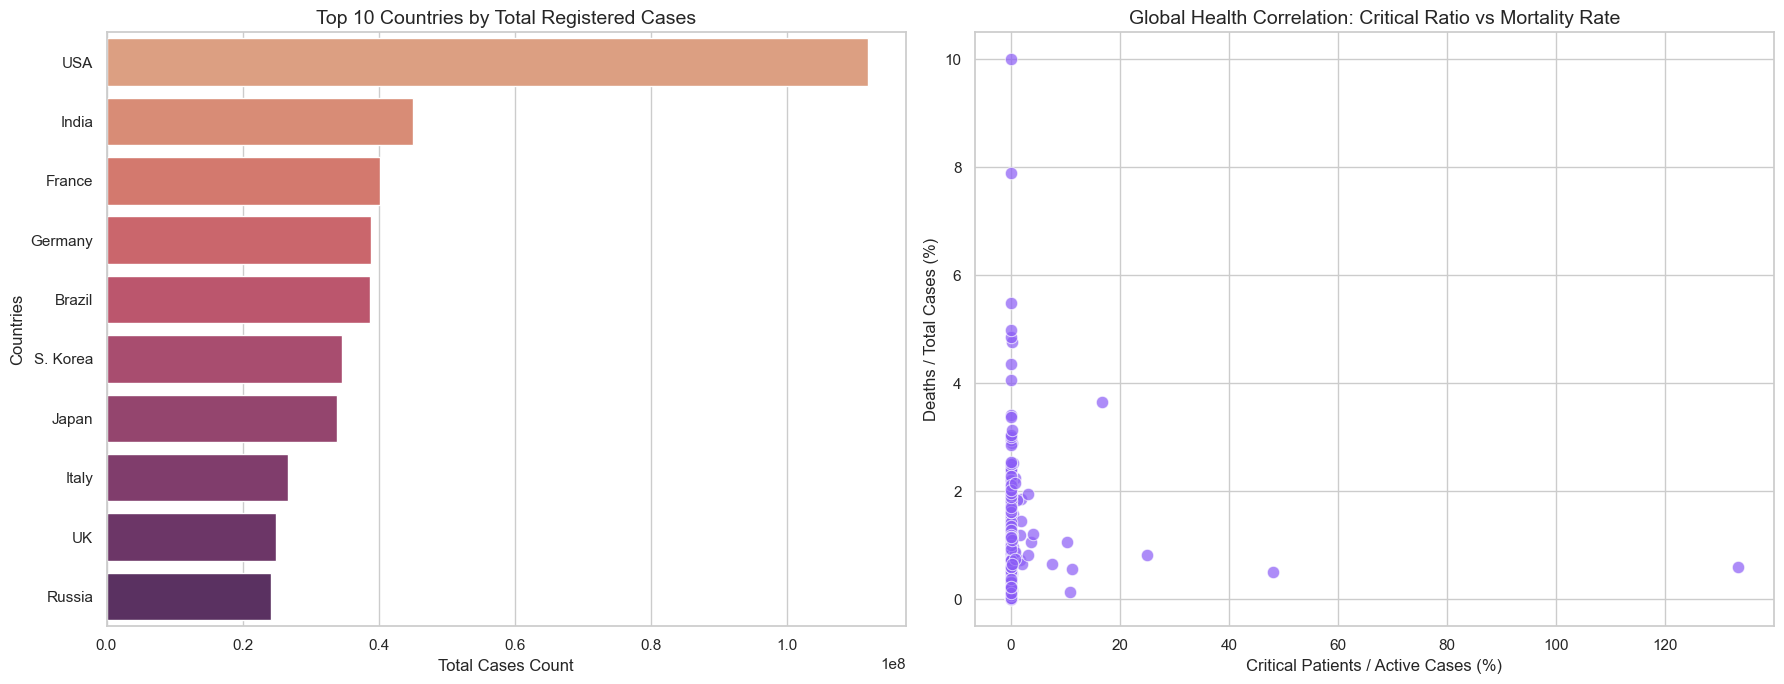

In [9]:
# Force inline notebook plotting
%matplotlib inline

# Set visualization style grid
sns.set_theme(style="whitegrid")

# Mine top country patterns
df_top_countries = extract_health_patterns(df_health_transformed)
print("Top 5 Countries Extracted Pattern:")
print(df_top_countries[["country", "cases", "deaths", "mortality_rate"]].head())

# Generate public health dashboard charts
plot_health_dashboard(df_health_transformed, df_top_countries)

In [10]:
def deploy_health_storage(dataframe, top_countries_df, output_path):
    # Define file path destinations
    csv_filename = os.path.join(output_path, "public_health_processed_data.csv")
    json_filename = os.path.join(output_path, "health_top_countries_summary.json")
    
    # Save transformed dataframe to disk
    dataframe.to_csv(csv_filename, index=False)
    
    # Convert top countries data to dictionary
    top_dict = top_countries_df.to_dict(orient="records")
    
    # Build dashboard report metadata
    final_report = {
        "dashboard_generated_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "total_countries_reported": len(dataframe),
        "top_affected_countries": top_dict
    }
    
    # Save json summary report document
    with open(json_filename, "w", encoding="utf-8") as f:
        json.dump(final_report, f, indent=4)
        
    print("Public health storage pipeline deployment completed successfully")

# Execute final dashboard storage
deploy_health_storage(df_health_transformed, df_top_countries, OUTPUT_DIR)

Public health storage pipeline deployment completed successfully
